In [1]:
import numpy as np
import sys
sys.path.append("../src")
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import glob
import os
from utils import time_embedding_np, reward_simulate,simulate_data_raw,make_weighted_target,position_encoder
from utils import best_next_state,path_opt,preward_opt,compute_normalized_future_rewards

In [2]:
base_reward = 10.0
map_name = "short"
decay_rate = 0.6
reward_period = 10 
session_duration = 500000
rewards_in_period = []

total_steps = session_duration
for period_start in range(0, total_steps, reward_period):
    period_end = min(period_start + reward_period, total_steps)
    steps_in_period = np.arange(period_start, period_end)
    rewards_in_period.extend(base_reward * (decay_rate ** (steps_in_period - period_start)))

pattern = [1,1,1,1,1,1,1,2,3,4,5,5,5,5,5,5,5,4,3,2]
optimal_states = np.array(pattern*(session_duration // len(pattern))).reshape(-1,1)


In [3]:
def get_close_colors(cmap_name, start=0.5, delta=0.15,n = 2):
    cmap = cm.get_cmap(cmap_name)
    cmap_color = [cmap(start + i*delta) for i in range(n)]
    return cmap_color[:n]

### Read Decision Forests Results

In [4]:
Ts_PAFM = [2**i for i in np.arange(7,8)]+[150,200,225,256,300,400,512]+[750]+[1024,1250,1500,2048]
step = 6
PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PAFM/DF/RF_oh_w_time128_2048_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PAFM):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
    PREWARDS_arr = np.vstack(PREWARDS)
    PREGRETS_PAFM_DF_arr = np.vstack(PREGRETS)
print(PREGRETS_PAFM_DF_arr.shape)


Ts_PVFM = [1000,5000,10000,20000,40000,80000,160000]
step = 6
PREWARDS = []
PREGRETS = []
for rep in [1,6,7,8,9]:
    if rep == 1:
        fn = f"../results/PVFM/DF/RF_oh_w_time1000_160000_lookahead{step}_array6.npz"
        data = np.load(fn)
        PREGRETS.append(data["pregrest"])
    else:
        fn = f"../results/PVFM/DF/RF_oh_w_time1000_80000_lookahead{step}_reps{rep}.npz"
        data = np.load(fn)
        states = data["future_states"]
        prewards = []
        pregrets = []
        for k,T in enumerate(Ts_PVFM[:-1]):
            irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
            preward = compute_normalized_future_rewards(irewards,100,0.5)
            path, ireward_opt = path_opt(states[k,0], T, 100)
            preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
            pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
            prewards.append(np.sum(preward).item())
            pregrets.append(pregret)
        PREWARDS.append(prewards)
        PREGRETS.append(pregrets+[np.nan])
PREGRETS_PVFM_DF_lookahead_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_DF_lookahead_arr.shape)



PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PVFM/DF/XGB_optimal_oh_w_time1000_160000_w_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_XGB_opt_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_XGB_opt_arr.shape)

PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PVFM/DF/RF_oh_w_time1000_80000_wo_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM[:-1]):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_DF_wo_lookahead_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_DF_wo_lookahead_arr.shape)

(10, 13)
(10, 7)
(10, 7)
(10, 6)


### Read NN Results

In [5]:
# PREWARDS = []
# PREGRETS = []
# for rep in range(10):
#     fn = f"../results/PVFM/NN_Yuxin/NN_oh_w_time1000_80000_lookahead{step}_reps{rep}.npz"
#     data = np.load(fn)
#     states = data["future_states"]
#     prewards = []
#     pregrets = []
#     for k,T in enumerate(Ts_PVFM[:-2]):
#         irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
#         preward = compute_normalized_future_rewards(irewards,100,0.5)
#         path, ireward_opt = path_opt(states[k,0], T, 100)
#         preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
#         pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
#         prewards.append(np.sum(preward).item())
#         pregrets.append(pregret)
#     PREWARDS.append(prewards)
#     PREGRETS.append(pregrets)
# PREGRETS_PVFM_NN_arr = np.vstack(PREGRETS)
# pregrets_80000 = np.array([1.49,1.85,2.1,2.01,1.29,1.07,1.19,1.69,1.62,1.51]).reshape(-1,1)
# PREGRETS_PVFM_NN_arr = np.hstack([PREGRETS_PVFM_NN_arr,pregrets_80000])
# print(PREGRETS_PVFM_NN_arr.shape)


PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PVFM/NN_Yuxin/NN_SameStructure_oh_w_time1000_80000_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM[:-2]):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_NN_arr = np.vstack(PREGRETS)
pregrets_80000 = np.array([1.49,1.85,2.1,2.01,1.29,1.07,1.19,1.69,1.62,1.51]).reshape(-1,1)
PREGRETS_PVFM_NN_arr = np.hstack([PREGRETS_PVFM_NN_arr,pregrets_80000])
print(PREGRETS_PVFM_NN_arr.shape)


PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PVFM/NN_Yuxin/NN_optimal_oh_w_time1000_80000_w_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM[:-1]):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_NN_opt_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_NN_opt_arr.shape)



PREWARDS = []
PREGRETS = []
for rep in range(1):
    fn = f"../results/PVFM/NN/NN_optimal_oh_w_time1000_80000_lookahead{step}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM[:-1]):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_NN_opt_zeyu_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_NN_opt_zeyu_arr.shape)


PREWARDS = []
PREGRETS = []
for rep in range(10):
    fn = f"../results/PVFM/NN/NN_oh_w_time1000_80000_lookahead{step}_reps{rep}.npz"
    data = np.load(fn)
    states = data["future_states"]
    prewards = []
    pregrets = []
    for k,T in enumerate(Ts_PVFM[:-1]):
        irewards = [reward_simulate(states[k,i],T+i,rewards_in_period) for i in range(1,states.shape[1])]
        preward = compute_normalized_future_rewards(irewards,100,0.5)
        path, ireward_opt = path_opt(states[k,0], T, 100)
        preward_opt = compute_normalized_future_rewards(ireward_opt[1:],100,0.5)
        pregret = (np.sum(preward_opt).item()-np.sum(preward).item())/100
        prewards.append(np.sum(preward).item())
        pregrets.append(pregret)
    PREWARDS.append(prewards)
    PREGRETS.append(pregrets)
PREGRETS_PVFM_NN_zeyu_arr = np.vstack(PREGRETS)
print(PREGRETS_PVFM_NN_zeyu_arr.shape)


(10, 6)
(10, 6)
(1, 6)
(10, 6)


# Plot

/var/folders/7s/xvdffqdj1bb5lm_5b2_s8lxw0000gn/T/ipykernel_26641/1671028746.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


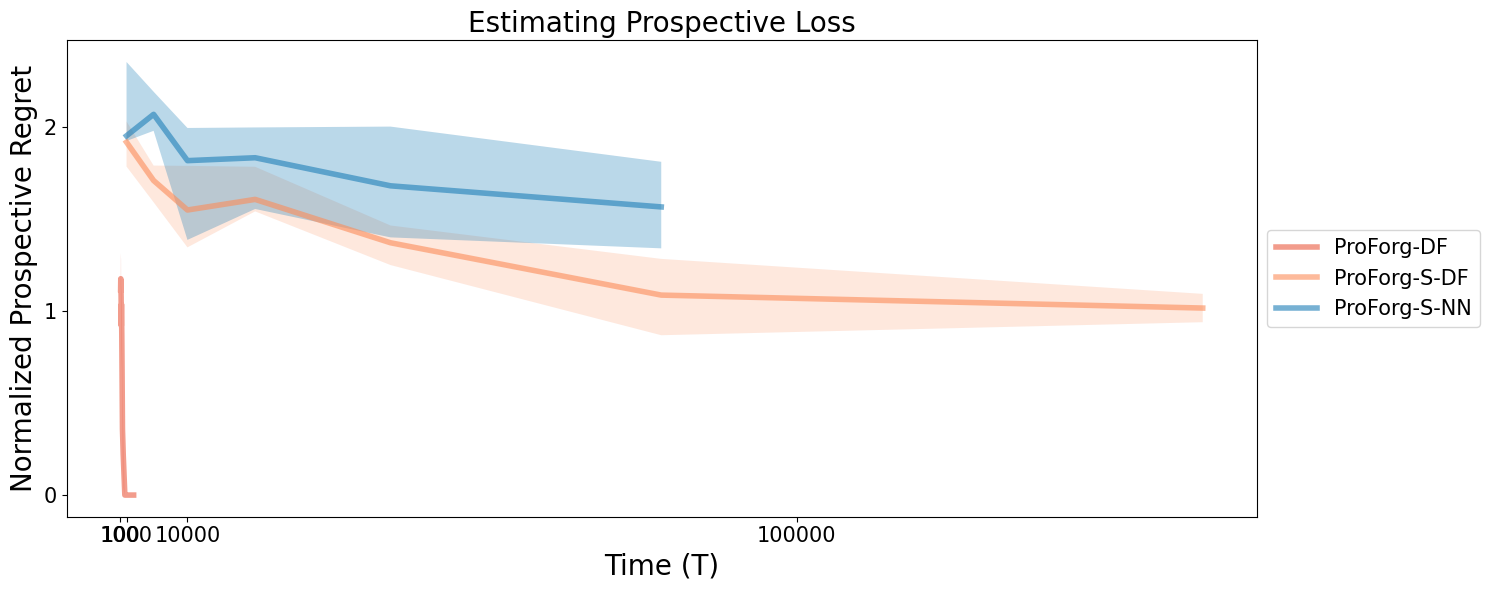

In [29]:
plt.figure(figsize=(15, 6))
linewidth = 4
fontsize = 20

pafm_df, pvfm_df = get_close_colors("OrRd", start = 0.65, delta = -0.15, n = 2) 
pvfm_nn, pvfm_nn_opt = get_close_colors("GnBu", start=0.8, delta=0.25,n = 2)
pvfm_zy, pvfm_nn_zy = get_close_colors("Greens", start=0.5, delta=0.25,n = 2)

colors = {
    "PAFM_oh_RF": pafm_df,
    "PVFM_oh_RF": pvfm_df,
    "PVFM_opt_RF":pvfm_df,
    "PVFM_oh_NN": pvfm_nn,
    "PVFM_oh_NN_zy": pvfm_zy,
    "PVFM_opt_NN":pvfm_nn_opt
    }

## Plot DF

median = np.median(PREGRETS_PAFM_DF_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PAFM_DF_arr, 75, axis=0)
plt.plot(Ts_PAFM, median,color=colors["PAFM_oh_RF"], lw = linewidth,alpha = 0.6,label = 'ProForg-DF')
plt.fill_between(Ts_PAFM, q25, q75, color=colors["PAFM_oh_RF"], alpha=0.20, edgecolor="none")


median = np.nanmedian(PREGRETS_PVFM_DF_lookahead_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PVFM_DF_lookahead_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PVFM_DF_lookahead_arr, 75, axis=0)
plt.plot(Ts_PVFM, median,color=colors["PVFM_oh_RF"], lw = linewidth,alpha = 0.6,label = 'ProForg-S-DF')
plt.fill_between(Ts_PVFM, q25, q75, color=colors["PVFM_oh_RF"], alpha=0.20, edgecolor="none")


median = np.min(PREGRETS_PVFM_XGB_opt_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_DF_opt_arr, 75, axis=0)
# plt.plot(Ts_PVFM, median,color=colors["PVFM_oh_RF"], lw = linewidth,alpha = 0.6,label = 'ProFrog-S-Oracle-DF',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_opt_RF"], alpha=0.25, edgecolor="none")

## Plot NN
median = np.median(PREGRETS_PVFM_NN_arr, axis=0)    
q25  = np.nanpercentile(PREGRETS_PVFM_NN_arr, 25, axis=0)
q75  = np.nanpercentile(PREGRETS_PVFM_NN_arr, 75, axis=0)
plt.plot(Ts_PVFM[:-1], median,color=colors["PVFM_oh_NN"], lw = linewidth,alpha = 0.6,label = 'ProForg-S-NN')
plt.fill_between(Ts_PVFM[:-1], q25, q75, color=colors["PVFM_oh_NN"], alpha=0.30, edgecolor="none")

# median = np.vstack([np.min(PREGRETS_PVFM_NN_opt_arr, axis=0)[:-1].reshape(-1,1),[0.7883]])
# q25  = np.nanpercentile(PREGRETS_PVFM_NN_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PVFM_NN_opt_arr, 75, axis=0)
# plt.plot(Ts_PVFM[:-1], median,color=colors["PVFM_oh_NN"], lw = linewidth,alpha = 0.6,label = 'ProFrog-S-Oracle-NN',marker='o',linestyle = '--')
# plt.fill_between(Ts_PVFM[:-1], q25, q75, color=colors["PVFM_oh_NN"], alpha=0.25, edgecolor="none")


#median = np.median(PREGRETS_PVFM_NN_zeyu_arr, axis=0)    
#q25  = np.nanpercentile(PREGRETS_PVFM_NN_zeyu_arr, 25, axis=0)
#q75  = np.nanpercentile(PREGRETS_PVFM_NN_zeyu_arr, 75, axis=0)
#plt.plot(Ts_PVFM[:-1], median,color=colors["PVFM_oh_NN_zy"], lw = linewidth,marker='o',alpha = 0.6,label = 'ProFrog-S-NN - Zeyu')
#plt.fill_between(Ts_PVFM[:-1], q25, q75, color=colors["PVFM_oh_NN_zy"], alpha=0.30, edgecolor="none")

#median = np.min(PREGRETS_PVFM_NN_opt_zeyu_arr, axis=0)    
# q25  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 25, axis=0)
# q75  = np.nanpercentile(PREGRETS_PAFM_NN_opt_arr, 75, axis=0)
# plt.plot(Ts_PVFM[:-1], median,color=colors["PVFM_oh_NN_zy"], lw = linewidth,alpha = 0.6,label = 'ProFrog-S-Oracle-NN - Zeyu',marker='o',linestyle = '--')
# plt.fill_between(Ts, q25, q75, color=colors["PAFM_oh_NN"], alpha=0.25, edgecolor="none")


plt.xlabel("Time (T)",fontsize = fontsize)
plt.ylabel("Normalized Prospective Regret", fontsize = fontsize)
#plt.xscale('log')

#xticks = [128, 150, 200, 225, 256, 300, 400, 512, 750, 1000, 1250, 1500, 2048, 5000, 10000, 20000, 40000, 80000, 160000]
#xticklabels = [str(v) if v in [128,256,512,1024,2048]+Ts_PVFM else ""   # hide every 2nd label
              # for i, v in enumerate(xticks)]

xticks = [100, 1000, 10000, 100000]
xticklabels = ["100", "1000", "10000", "100000"]

plt.xticks(xticks, labels=xticklabels, fontsize=fontsize-5)


#for tick in xticks:
    #plt.axvline(x = tick, color = 'gray', alpha = 0.2, linewidth = .5)

#plt.xticks(xticks, labels=xticklabels,fontsize = fontsize-5)

# plt.xticks(Ts_PAFM+Ts_PVFM, labels=[str(v) for v in Ts_PAFM+Ts_PVFM])
plt.yticks([0,1,2],fontsize = fontsize-5)
plt.title('Estimating Prospective Loss',fontsize = fontsize)
# plt.xlim(0,700000)                  
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5),fontsize = fontsize-5)
#plt.grid(True, linestyle='--', alpha=0.2)
plt.tight_layout()

In [7]:
xticks

[np.int64(128), np.int64(256), 1000, 5000, 10000, 20000, 40000, 80000, 160000]